# AI Predictive Maintenance for EV Manufacturing

Research question: How can AI reduce unplanned downtime in EV manufacturing at Jaguar Land Rover?

This notebook uses the AI4I 2020 Predictive Maintenance Dataset (UCI ML Repository) as a proxy for JLR-style equipment: CNC machines, conveyors, robotic cells, motors. It's not real JLR data, but the sensor features are representative enough to show how machine data can be used to estimate failure risk.

Notebook sections:
1. Smart factory context: where this model fits in a JLR production environment
2. Exploratory data analysis
3. Model experiment: three classifiers, cost-aware threshold selection, cross-validation
4. Fairness check: does the model perform equally across machine types?
5. Fault type analysis: can we predict *what* will fail, not just *that* it will?
6. Demo output: explainability and maintenance recommendations
7. Ethics, risk, and deployment considerations

> This is a fault prediction and maintenance scheduling project, not a Remaining Useful Life (RUL) model.

---
## Smart Factory Context: Where Does This Model Fit?

A predictive maintenance model is just one piece of a broader smart factory architecture. At JLR, deploying something like this would involve three layers working together:

```
SENSING LAYER              COMPUTE LAYER                 ACTION LAYER
─────────────────          ─────────────────────────     ──────────────────────────
CNC spindle sensors  ───►  Data pipeline                 CMMS work order raised
Motor temperature          (MQTT / OPC-UA → Kafka)  ───► Maintenance team alerted
Torque & power draw        Feature engineering            Spare parts pre-ordered
Tool wear counters         Model inference (<1s)          Line supervisor notified
Conveyor tension           Risk tier output               Shift plan adjusted
```

Sensing requirements for this model:
- Minimum viable: temperature, torque, rotational speed, tool wear counter (all present in the AI4I features).
- Enhanced: vibration (FFT spectrum), acoustic emission, power quality harmonics.
- Ideal: all of the above plus digital twin synchronisation for physics-informed drift detection.

Supply chain integration: if a failure is predicted 48–72 hours ahead, the CMMS can trigger a spare-parts request before the engineer even starts the inspection. At JLR this could integrate with existing SAP PM infrastructure: converting a reactive emergency parts order into a planned procurement, cutting both lead time and freight costs.

What this notebook shows vs what a real deployment would need:

| Capability | This notebook | Full deployment |
|---|---|---|
| Failure onset prediction | ✅ | ✅ + real-time streaming |
| Risk-tiered recommendations | ✅ | ✅ + CMMS integration |
| Explainability per machine | ✅ (LIME/SHAP) | ✅ + engineer UI |
| Fault type identification | ✅ (indicative) | Requires more labelled data |
| Remaining Useful Life | ❌ | Future extension |
| Real JLR sensor data | ❌ (proxy dataset) | Required for production |

In [17]:
# NOTE: Setup imports, environment checks, and display configuration
import importlib, json, subprocess, sys

required = {'ucimlrepo': 'ucimlrepo', 'pytorch_tabnet': 'pytorch-tabnet', 'shap': 'shap', 'lime': 'lime'}
missing = [pip for mod, pip in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + missing)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import torch
import joblib
from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from pathlib import Path

ROOT_DIR = Path.cwd().resolve().parent
DATA_CACHE_PATH = ROOT_DIR / 'data' / 'ai4i_2020_cached.csv'
ARTIFACTS_DIR = ROOT_DIR / 'artifacts'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
APP_PAYLOAD_PATH = ARTIFACTS_DIR / 'app_payload.json'
MODEL_BUNDLE_PATH = ARTIFACTS_DIR / 'model_bundle.joblib'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
np.random.seed(42)
print('Setup complete. CUDA available:', torch.cuda.is_available())


Setup complete. CUDA available: True


---
## How to read this notebook

This notebook goes from raw data to a working demo app. Run the cells in order, top to bottom.

What each section does:
1. Smart factory context: where this model would sit in a real JLR deployment
2. EDA: exploring the data before modelling (class balance, sensor patterns, correlations)
3. Preprocessing: encoding `Type`, scaling numeric features, splitting into train/val/test
4. Model experiment: training and comparing Logistic Regression, Random Forest, and TabNet
5. Threshold selection: picking an operating threshold based on the cost of getting it wrong, not just accuracy
6. Cross-validation: checking that performance is stable across different data splits, not just one lucky split
7. Fairness check: does the model work equally well for all machine types (L/M/H)?
8. Fault type analysis: a rough look at whether we can predict *what* will fail, not just *that* it will
9. Demo section: SHAP and LIME explainability, plus the maintenance recommendation output
10. Ethics and deployment: risks and practical considerations for a real deployment
11. Export: saves the model artefacts the web app needs. Run this before starting the app.

Key variables:
| Variable | What it is |
|---|---|
| `df` | Full AI4I dataset (10,000 records, 13 columns including failure labels) |
| `X_train`, `X_val`, `X_test` | Feature splits (6 sensor columns) |
| `y_train`, `y_val`, `y_test` | Corresponding failure labels (0 = normal, 1 = failure) |
| `preprocessor` | sklearn `ColumnTransformer`: one-hot encodes `Type`, scales numeric features |
| `trained_models` | Dict of the three fitted models: `'Logistic Regression'`, `'Random Forest'`, `'TabNet'` |
| `probability_outputs_test` | Dict of predicted failure probabilities on the held-out test set |
| `optimal_thresholds` | Decision threshold chosen per model on the validation set |
| `dashboard_export` | Test set with predictions, risk levels, and recommendations attached |

How this connects to the app: the final cell writes two files into `artifacts/`:
- `app_payload.json`: all the data the frontend needs (machine list, metrics, LIME explanations, figures)
- `model_bundle.joblib`: the trained Random Forest and preprocessor for live predictions

After running the full notebook, start the demo with `app/run_demo.ps1` (or `python app/demo_backend.py`).

Why Random Forest was chosen: the three models are compared on a cost-aware basis. Missing a real failure costs £1,000 (unplanned downtime estimate); a false alarm costs £10 (wasted inspection). Whichever model and threshold combination gives the lowest estimated cost on the held-out test set wins. This is more meaningful than accuracy, which would be dominated by the 96.6% of records that are normal.

In [18]:
# NOTE: Load AI4I dataset into `df` and define feature/failure mode lists
if DATA_CACHE_PATH.exists():
    df = pd.read_csv(DATA_CACHE_PATH)
    print(f'Loaded cached dataset from {DATA_CACHE_PATH}')
else:
    print('Local cache not found. Downloading AI4I dataset from UCI...')
    from ucimlrepo import fetch_ucirepo
    try:
        ai4i = fetch_ucirepo(id=601)
    except Exception as exc:
        raise RuntimeError('Dataset download failed and no local cache was available.') from exc

    X_raw = ai4i.data.features.copy()
    y_raw = ai4i.data.targets.copy()
    X_raw = X_raw.rename(columns={
        'Air temperature': 'Air temperature [K]',
        'Process temperature': 'Process temperature [K]',
        'Rotational speed': 'Rotational speed [rpm]',
        'Torque': 'Torque [Nm]',
        'Tool wear': 'Tool wear [min]',
    })
    df = pd.concat([X_raw, y_raw], axis=1)
    DATA_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(DATA_CACHE_PATH, index=False)
    print(f'Dataset downloaded and cached at {DATA_CACHE_PATH}')

df.insert(0, 'Machine ID', [f'AI4I_{i:05d}' for i in range(1, len(df) + 1)])

FAILURE_MODE_COLS = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
FEATURE_COLS = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

print(f'Dataset: {df.shape[0]:,} records, {df.shape[1]} columns')
print(f'Failure rate: {df["Machine failure"].mean():.1%}  ({df["Machine failure"].sum()} failures out of {len(df):,})')
display(df.head(3))

Loaded cached dataset from C:\Users\amyna\OneDrive - University of Warwick\AI for industry\Group_work\data\ai4i_2020_cached.csv
Dataset: 10,000 records, 13 columns
Failure rate: 3.4%  (339 failures out of 10,000)


,Machine ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,AI4I_00001,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,AI4I_00002,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,AI4I_00003,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


---
## 1. Exploratory Data Analysis

Three things to check before modelling:
- How bad is the class imbalance, and which failure modes are most common?
- Do failed machines look noticeably different from healthy ones in the sensor data?
- Which sensor features correlate most with failure?

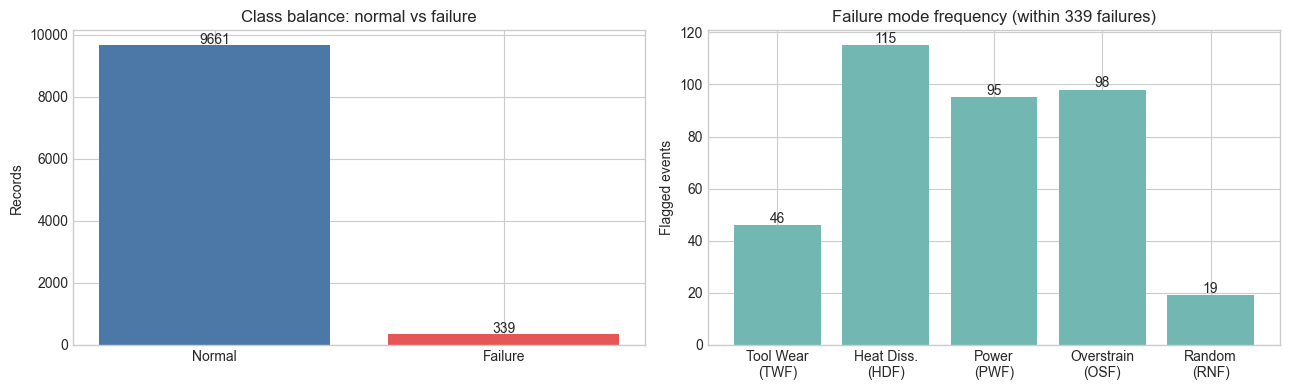

3.4% failure rate is typical for industrial predictive maintenance datasets.
Heat Dissipation (115) and Overstrain (98) are the most common failure modes.


In [19]:
# NOTE: EDA: plot class balance and failure mode frequency
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['Machine failure'].value_counts().sort_index()
axes[0].bar(['Normal', 'Failure'], counts.values, color=['#4C78A8', '#E45756'])
axes[0].set_title('Class balance: normal vs failure')
axes[0].set_ylabel('Records')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, str(v), ha='center')

mode_labels = {'TWF': 'Tool Wear\n(TWF)', 'HDF': 'Heat Diss.\n(HDF)',
               'PWF': 'Power\n(PWF)', 'OSF': 'Overstrain\n(OSF)', 'RNF': 'Random\n(RNF)'}
mode_counts = df[FAILURE_MODE_COLS].sum()
axes[1].bar([mode_labels[c] for c in mode_counts.index], mode_counts.values, color='#72B7B2')
axes[1].set_title('Failure mode frequency (within 339 failures)')
axes[1].set_ylabel('Flagged events')
for i, v in enumerate(mode_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()
print('3.4% failure rate is typical for industrial predictive maintenance datasets.')
print('Heat Dissipation (115) and Overstrain (98) are the most common failure modes.')

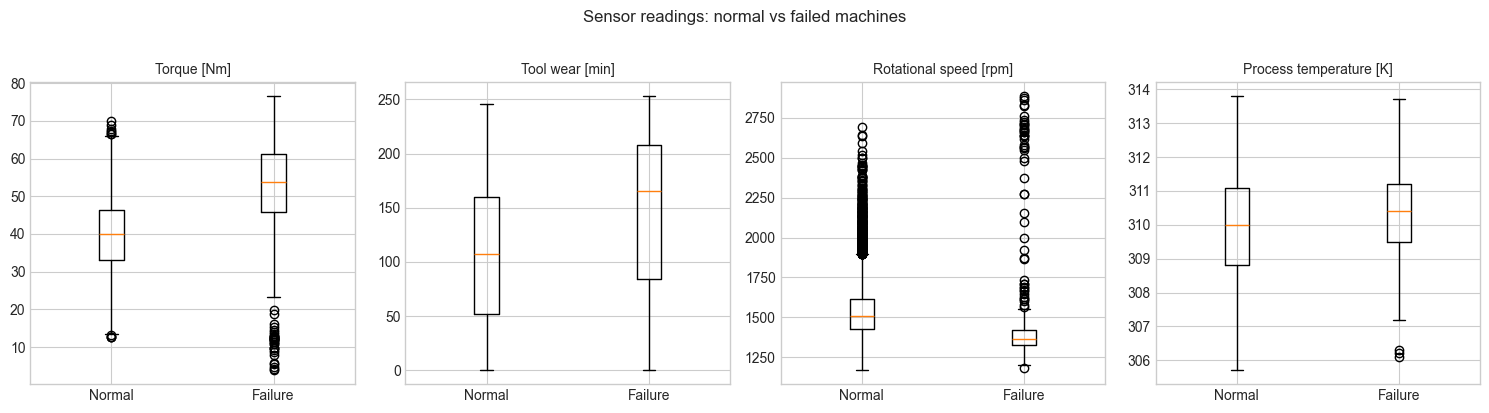

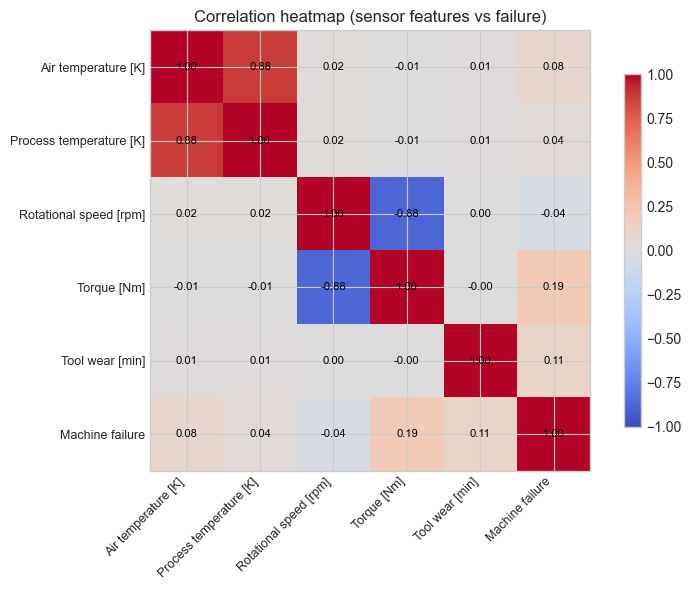

Key finding: no single sensor clearly separates the classes, which is why a multi-feature model is needed.


In [20]:
# NOTE: EDA: boxplots comparing sensors for normal vs failed machines and correlation heatmap
# Box plots: do failed machines look different from normal ones?
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
boxplot_features = ['Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]', 'Process temperature [K]']

for ax, feat in zip(axes, boxplot_features):
    ax.boxplot(
        [df.loc[df['Machine failure'] == 0, feat], df.loc[df['Machine failure'] == 1, feat]],
        tick_labels=['Normal', 'Failure'],
    )
    ax.set_title(feat, fontsize=10)

plt.suptitle('Sensor readings: normal vs failed machines', y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_cols = FEATURE_COLS[1:] + ['Machine failure']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation heatmap (sensor features vs failure)')
plt.tight_layout()
plt.show()
print('Key finding: no single sensor clearly separates the classes, which is why a multi-feature model is needed.')

EDA takeaway:
- Failed machines tend to have higher torque, higher tool wear, and lower rotational speed.
- Temperature features are correlated with each other but not strongly with failure on their own.
- No single sensor clearly separates healthy from failing machines, which is why a multi-feature model is needed.

---
## 2. Model Experiment

### Preprocessing

Only the six sensor-style features are used as model inputs. The failure mode columns (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) are deliberately excluded because they are post-event diagnostic labels, not observable sensor readings. Including them would be data leakage: they are only assigned after a failure is confirmed, so they would not be available at prediction time.

- `Type` (machine quality grade: L/M/H) is one-hot encoded.
- Numeric features are standardised (zero mean, unit variance).
- Stratified 80/20 split preserves the 3.4% failure rate in both partitions.

In [21]:
# NOTE: Preprocessing: build X/y, create train/validation/test splits, and fit ColumnTransformer
X_model = df[FEATURE_COLS]
y_model = df['Machine failure'].astype(int)

# First hold out a final test set. This is touched only once after model/threshold selection is complete.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_model, y_model, test_size=0.20, random_state=42, stratify=y_model
)

# Split the remaining data again so thresholds can be chosen on validation data rather than the test set.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

preprocessor = ColumnTransformer(transformers=[
    ('cat', build_one_hot_encoder(), cat_features),
    ('num', StandardScaler(), num_features),
])

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)
feature_names = (
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))
    + num_features
)

print(f'Train: {X_train.shape}  |  Validation: {X_val.shape}  |  Test: {X_test.shape}')
print(
    f'Failure rates:  train {y_train.mean():.1%}  |  '
    f'val {y_val.mean():.1%}  |  test {y_test.mean():.1%}'
)
print(f'Prepared feature count: {len(feature_names)}  →  {feature_names}')

Train: (6400, 6)  |  Validation: (1600, 6)  |  Test: (2000, 6)
Failure rates:  train 3.4%  |  val 3.4%  |  test 3.4%
Prepared feature count: 8  →  ['Type_H', 'Type_L', 'Type_M', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


### Three models

| Model | Rationale |
|---|---|
| Logistic Regression | Interpretable linear baseline with reasonable probability calibration |
| Random Forest | Main non-linear model; robust to outliers; provides feature importance |
| TabNet | Neural network designed for tabular data; included as a deep learning comparison |

All models use `class_weight='balanced'` (or equivalent) because the 3.4% failure rate means a model that always predicts "no failure" would score 96.6% accuracy while being completely useless.

In [22]:
# NOTE: Train models: Logistic Regression, Random Forest, and TabNet
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

sklearn_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
}

trained_models = {}
probability_outputs_val = {}
probability_outputs_test = {}

for name, model in sklearn_models.items():
    model.fit(X_train_prep, y_train)
    trained_models[name] = model
    probability_outputs_val[name] = model.predict_proba(X_val_prep)[:, 1]
    probability_outputs_test[name] = model.predict_proba(X_test_prep)[:, 1]
    print(f'{name}: trained')

# TabNet uses the same validation split for early stopping and threshold tuning.
tabnet = TabNetClassifier(seed=42, verbose=0, device_name=DEVICE)
tabnet.fit(
    X_train_prep.astype(np.float32), y_train.to_numpy(),
    eval_set=[(X_val_prep.astype(np.float32), y_val.to_numpy())],
    eval_name=['val'], eval_metric=['auc'],
    max_epochs=30, patience=10, batch_size=1024, virtual_batch_size=128,
)
trained_models['TabNet'] = tabnet
probability_outputs_val['TabNet'] = tabnet.predict_proba(X_val_prep.astype(np.float32))[:, 1]
probability_outputs_test['TabNet'] = tabnet.predict_proba(X_test_prep.astype(np.float32))[:, 1]
print(f'TabNet: trained  (device: {DEVICE})')

Logistic Regression: trained
Random Forest: trained
Stop training because you reached max_epochs = 30 with best_epoch = 27 and best_val_auc = 0.92399
TabNet: trained  (device: cuda)


### Why threshold choice matters (and why Random Forest can look weaker at a shared cutoff)

Comparing models at a single fixed threshold like `0.50` is misleading because they produce probabilities on different scales:

- Logistic Regression produces well-spread probabilities, so true failures tend to land above moderate thresholds.
- Random Forest often gives lower probabilities to minority-class events under heavy class imbalance, even when it is actually better at separating the classes.
- TabNet can also behave differently from the sklearn models in how it distributes probabilities.

A fair comparison therefore needs to:
1. choose each model's threshold on a validation split
2. lock that threshold
3. evaluate once on the held-out test set

This stops us from gaming the test set to make one model look better.

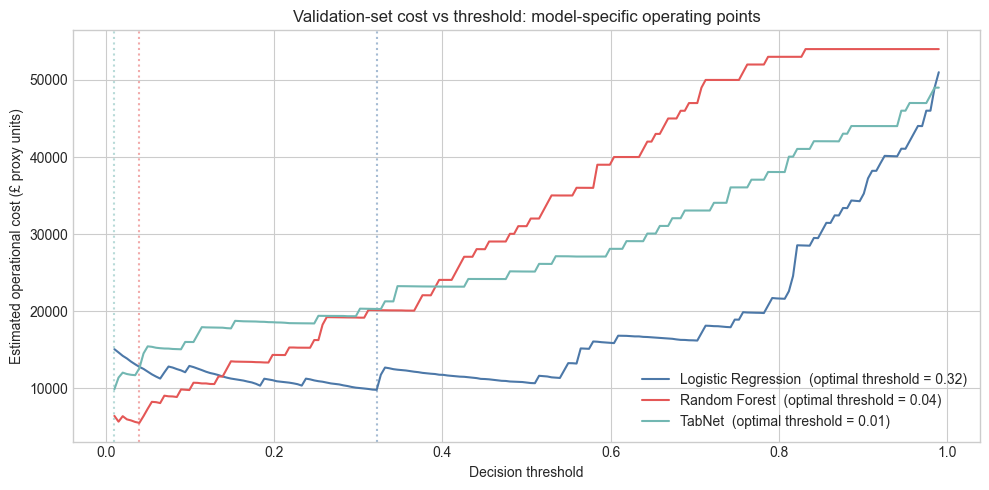

Thresholds chosen on validation data:
  Logistic Regression: 0.32
  Random Forest: 0.04
  TabNet: 0.01

These thresholds are now frozen before the final test-set evaluation.


In [23]:
# NOTE: Compute operational cost across thresholds on the validation set and lock thresholds before test evaluation
# Cost parameters: missing a failure is far costlier than a false alarm
# A conservative proxy: unplanned downtime ~£1,000/hr; inspection call-out ~£10
COST_FN = 1000   # cost of missing a real failure (false negative)
COST_FP = 10     # cost of unnecessary inspection (false positive)

threshs = np.linspace(0.01, 0.99, 199)
optimal_thresholds = {}
colors = {'Logistic Regression': '#4C78A8', 'Random Forest': '#E45756', 'TabNet': '#72B7B2'}

fig, ax = plt.subplots(figsize=(10, 5))
for name, probs in probability_outputs_val.items():
    costs = []
    for t in threshs:
        preds = (probs >= t).astype(int)
        fn = int(((y_val == 1) & (preds == 0)).sum())
        fp = int(((y_val == 0) & (preds == 1)).sum())
        costs.append(fn * COST_FN + fp * COST_FP)
    best_idx = int(np.argmin(costs))
    optimal_thresholds[name] = threshs[best_idx]
    ax.plot(threshs, costs, label=f'{name}  (optimal threshold = {threshs[best_idx]:.2f})', color=colors[name])
    ax.axvline(threshs[best_idx], linestyle=':', color=colors[name], alpha=0.5)

ax.set_xlabel('Decision threshold')
ax.set_ylabel('Estimated operational cost (£ proxy units)')
ax.set_title('Validation-set cost vs threshold: model-specific operating points')
ax.legend()
plt.tight_layout()
plt.show()

print('Thresholds chosen on validation data:')
for name, t in optimal_thresholds.items():
    print(f'  {name}: {t:.2f}')
print()
print('These thresholds are now frozen before the final test-set evaluation.')


In [24]:
# NOTE: 5-fold Stratified CV to estimate ROC-AUC stability for LR and RF on the development data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

cv_models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)),
    ]),
}

for name, estimator in cv_models.items():
    auc_scores = cross_val_score(estimator, X_trainval, y_trainval, cv=cv, scoring='roc_auc')
    cv_rows.append({'Model': name, 'CV ROC-AUC mean': auc_scores.mean(), 'CV ROC-AUC std': auc_scores.std()})

cv_df = pd.DataFrame(cv_rows)
print('5-fold cross-validation on the development data (ROC-AUC is threshold-independent):')
display(cv_df.round(3))
print('RF has consistently higher and more stable AUC across folds.')
print('Threshold tuning is handled separately on the validation split.')


5-fold cross-validation on the development data (ROC-AUC is threshold-independent):


,Model,CV ROC-AUC mean,CV ROC-AUC std
0,Logistic Regression,0.897,0.016
1,Random Forest,0.966,0.012


RF has consistently higher and more stable AUC across folds.
Threshold tuning is handled separately on the validation split.


In [25]:
# NOTE: Evaluate each model once on the held-out test set using thresholds frozen from validation
results = []
opt_preds = {}

for name, probs in probability_outputs_test.items():
    t = optimal_thresholds[name]
    preds = (probs >= t).astype(int)
    opt_preds[name] = preds
    fn = int(((y_test == 1) & (preds == 0)).sum())
    fp = int(((y_test == 0) & (preds == 1)).sum())
    results.append({
        'Model': name,
        'Threshold': round(t, 2),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'F1': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probs),
        'Missed failures': fn,
        'False alarms': fp,
        'Est. cost (£)': fn * COST_FN + fp * COST_FP,
    })

results_df = pd.DataFrame(results).sort_values('Est. cost (£)')
print('Held-out test set comparison using validation-tuned thresholds:')
display(results_df.round(3))
best_model_name = results_df.iloc[0]['Model']
print(f'\nRecommended model: {best_model_name} (lowest estimated operational cost on the test set)')


Held-out test set comparison using validation-tuned thresholds:


,Model,Threshold,Recall,Precision,F1,ROC-AUC,Missed failures,False alarms,Est. cost (£)
1,Random Forest,0.04,0.926,0.262,0.409,0.963,5,177,6770
2,TabNet,0.01,0.882,0.158,0.268,0.926,8,319,11190
0,Logistic Regression,0.32,0.912,0.096,0.173,0.906,6,585,11850



Recommended model: Random Forest (lowest estimated operational cost on the test set)


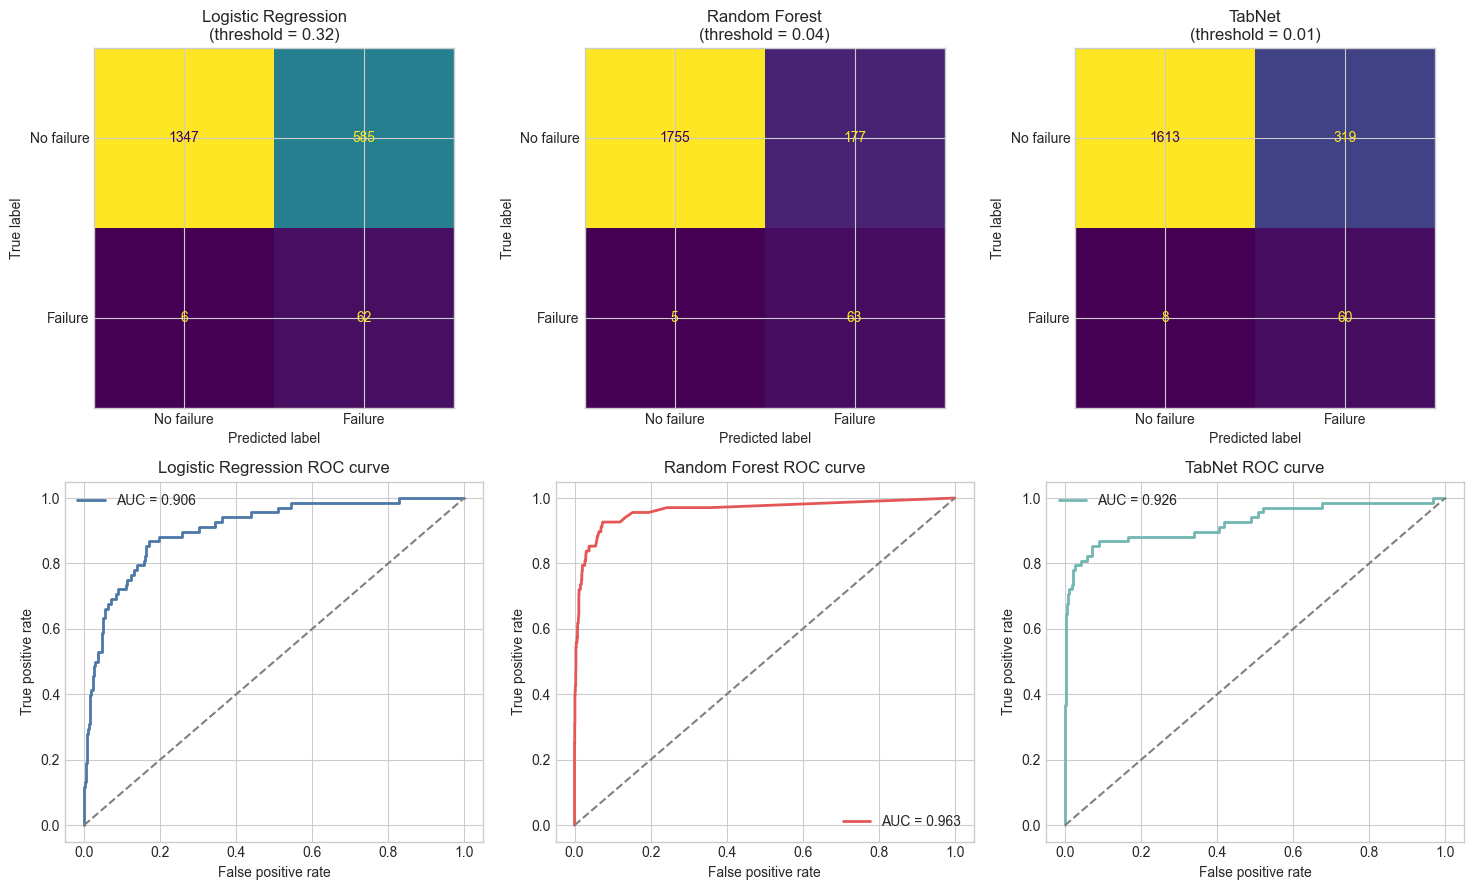

In [26]:
# NOTE: Plot confusion matrices and ROC curves for each model at the frozen thresholds
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
model_names = ['Logistic Regression', 'Random Forest', 'TabNet']

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, opt_preds[name])
    ConfusionMatrixDisplay(cm, display_labels=['No failure', 'Failure']).plot(
        ax=axes[0, i], colorbar=False
    )
    axes[0, i].set_title(f'{name}\n(threshold = {optimal_thresholds[name]:.2f})')

for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, probability_outputs_test[name])
    auc = roc_auc_score(y_test, probability_outputs_test[name])
    axes[1, i].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color=list(colors.values())[i], lw=2)
    axes[1, i].plot([0, 1], [0, 1], '--', color='grey')
    axes[1, i].set_title(f'{name} ROC curve')
    axes[1, i].set_xlabel('False positive rate')
    axes[1, i].set_ylabel('True positive rate')
    axes[1, i].legend()

plt.tight_layout()
plt.show()


---
## 3. Fairness Check: Does the Model Perform Equally Across Machine Types?

The dataset has three machine quality grades: L (low), M (medium), H (high). If the model consistently misses more failures for one type, those machines get less protection from the system. That is worth checking before deploying.

In practice: if all L-grade machines are on one production line and the model misses more failures there, that line ends up with more unplanned downtime than the others.

Random Forest fairness check by machine type:


,Type,Records,Failures,Recall,Precision,False alarm rate,Note
0,H,214,5,1.000,0.161,0.124,
1,L,1170,38,0.921,0.259,0.088,
2,M,616,25,0.920,0.311,0.086,


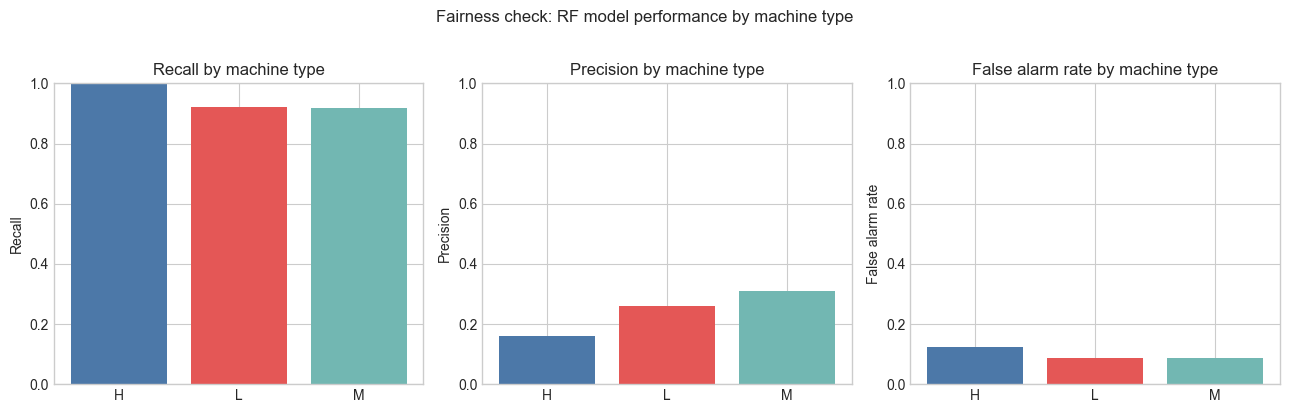


If recall is noticeably lower for one type, those machines get less protection from the system.
To address this, monitor per-type recall in production and adjust thresholds by type if a gap persists.


In [27]:
# NOTE: Fairness check: compute per-Type recall/precision/false-alarm rate using the RF threshold
rf_threshold = optimal_thresholds['Random Forest']
rf_probs_arr = probability_outputs_test['Random Forest']

fairness_df = X_test[['Type']].copy()
fairness_df['y_true'] = y_test.values
fairness_df['y_pred'] = (rf_probs_arr >= rf_threshold).astype(int)

rows = []
for mtype in sorted(fairness_df['Type'].unique()):
    sub = fairness_df[fairness_df['Type'] == mtype]
    n_fail = int(sub['y_true'].sum())
    n_normal = int((sub['y_true'] == 0).sum())
    if n_fail < 3:
        rows.append({'Type': mtype, 'Records': len(sub), 'Failures': n_fail,
                     'Recall': 'n/a', 'Precision': 'n/a', 'False alarm rate': 'n/a',
                     'Note': 'too few failures to assess'})
        continue
    rec = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
    prec = precision_score(sub['y_true'], sub['y_pred'], zero_division=0)
    far = round((((sub['y_pred'] == 1) & (sub['y_true'] == 0)).sum()) / max(n_normal, 1), 3)
    rows.append({'Type': mtype, 'Records': len(sub), 'Failures': n_fail,
                 'Recall': round(rec, 3), 'Precision': round(prec, 3),
                 'False alarm rate': far, 'Note': ''})

fairness_result = pd.DataFrame(rows)
print('Random Forest fairness check by machine type:')
display(fairness_result)

plottable = fairness_result[fairness_result['Note'] == ''].copy()
plottable[['Recall', 'Precision', 'False alarm rate']] = plottable[['Recall', 'Precision', 'False alarm rate']].astype(float)

if len(plottable) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    bar_colors = ['#4C78A8', '#E45756', '#72B7B2']
    for ax, metric in zip(axes, ['Recall', 'Precision', 'False alarm rate']):
        ax.bar(plottable['Type'], plottable[metric],
               color=bar_colors[:len(plottable)])
        ax.set_title(metric + ' by machine type')
        ax.set_ylim(0, 1)
        ax.set_ylabel(metric)
    plt.suptitle('Fairness check: RF model performance by machine type', y=1.02)
    plt.tight_layout()
    plt.show()

print()
print('If recall is noticeably lower for one type, those machines get less protection from the system.')
print('To address this, monitor per-type recall in production and adjust thresholds by type if a gap persists.')

---
## 4. Fault Type Analysis: Can We Predict *What* Will Fail?

The dataset includes five failure mode labels, assigned after a failure is confirmed:

| Code | Mode | Count | Predictable from sensors? |
|---|---|---|---|
| HDF | Heat Dissipation Failure | 115 | Yes: temperature differential is a signal |
| OSF | Overstrain Failure | 98 | Yes: torque × tool wear interaction |
| PWF | Power Failure | 95 | Partly: speed and torque can indicate power stress |
| TWF | Tool Wear Failure | 46 | Partly: tool wear counter, but threshold varies by material |
| RNF | Random Failure | 19 | No: assigned when no engineering cause is found |

These labels are not usable as model inputs because that would be data leakage. But we can ask a separate exploratory question: given the sensor readings at the time of failure, can a secondary classifier work out which mode caused it?

This is a limited side experiment:
- Small sample (~300 single-mode records, 4 classes after excluding RNF)
- Feature overlap between modes (OSF and TWF both involve high tool wear, for instance)
- Results should be treated as rough indicators, not a deployable classifier

Total failures: 339
Single-mode failures (usable for classification): 306
Multi-mode failures (excluded, ambiguous label): 24



,Count
fault_label,
Heat Dissipation,106
Power,80
Overstrain,78
Tool Wear,42



Exploratory hold-out accuracy: 0.92
5-fold CV accuracy: 0.96 ± 0.02
Random chance baseline: 0.25


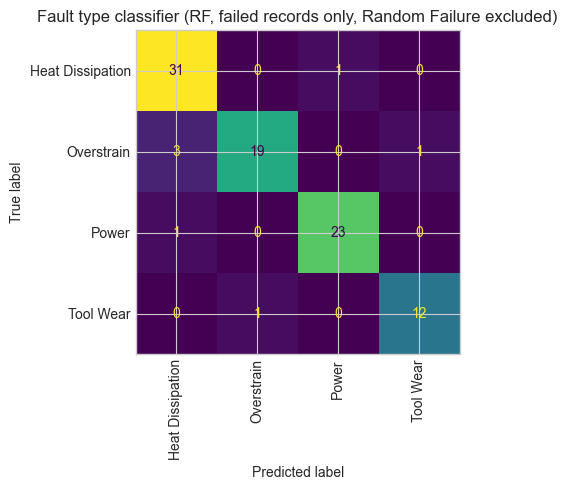


Heat Dissipation and Overstrain appear easier to distinguish from the sensor patterns.
Tool Wear and Power failure are more overlapping and therefore harder to separate.
Random Failure (excluded) cannot be predicted by definition.

This suggests there is signal for fault-type classification,
but the sample is too small to claim a production-grade classifier.


In [28]:
# NOTE: Fault-type classification experiment: exploratory only
failed = df[df['Machine failure'] == 1].copy()
single_mode_mask = failed[FAILURE_MODE_COLS].sum(axis=1) == 1
fault_df = failed[single_mode_mask].copy()
fault_df['fault_type'] = fault_df[FAILURE_MODE_COLS].idxmax(axis=1)

mode_names = {'TWF': 'Tool Wear', 'HDF': 'Heat Dissipation', 'PWF': 'Power', 'OSF': 'Overstrain', 'RNF': 'Random'}
fault_df['fault_label'] = fault_df['fault_type'].map(mode_names)

print(f'Total failures: {len(failed)}')
print(f'Single-mode failures (usable for classification): {len(fault_df)}')
print(f'Multi-mode failures (excluded, ambiguous label): {(failed[FAILURE_MODE_COLS].sum(axis=1) > 1).sum()}')
print()
display(fault_df['fault_label'].value_counts().to_frame('Count'))

# Exclude Random Failure (inherently unpredictable, n=19)
classifiable = fault_df[fault_df['fault_type'] != 'RNF'].copy()
X_fault = preprocessor.transform(classifiable[FEATURE_COLS])
le = LabelEncoder()
y_fault = le.fit_transform(classifiable['fault_label'])

X_ft, X_fv, y_ft, y_fv = train_test_split(
    X_fault, y_fault, test_size=0.30, random_state=42, stratify=y_fault
)

rf_fault = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf_fault.fit(X_ft, y_ft)
fault_preds = rf_fault.predict(X_fv)

fault_cv = cross_val_score(
    RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    X_fault, y_fault,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

acc = accuracy_score(y_fv, fault_preds)
chance = 1 / len(le.classes_)
print(f'\nExploratory hold-out accuracy: {acc:.2f}')
print(f'5-fold CV accuracy: {fault_cv.mean():.2f} ± {fault_cv.std():.2f}')
print(f'Random chance baseline: {chance:.2f}')

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_fv, fault_preds), display_labels=le.classes_
).plot(ax=ax, colorbar=False, xticks_rotation='vertical')
ax.set_title('Fault type classifier (RF, failed records only, Random Failure excluded)')
plt.tight_layout()
plt.show()

print()
print('Heat Dissipation and Overstrain appear easier to distinguish from the sensor patterns.')
print('Tool Wear and Power failure are more overlapping and therefore harder to separate.')
print('Random Failure (excluded) cannot be predicted by definition.')
print()
print('This suggests there is signal for fault-type classification,')
print('but the sample is too small to claim a production-grade classifier.')

---
## 5. Demo: From Prediction to Maintenance Action

This section is what gets shown in the presentation. It uses the Random Forest model with a threshold chosen on validation data to:
1. Show which features drive failure risk across all machines (SHAP and feature importance).
2. Explain why a specific machine was flagged (LIME: a local, per-machine explanation).
3. Produce a maintenance dashboard that separates:
   - probability-based risk tiers
   - the lower operating threshold used to flag borderline cases for human review

### Feature importance and SHAP

Feature importance answers: which sensors matter most across all predictions?
SHAP answers: how much did each feature push this particular prediction towards failure or away from it?

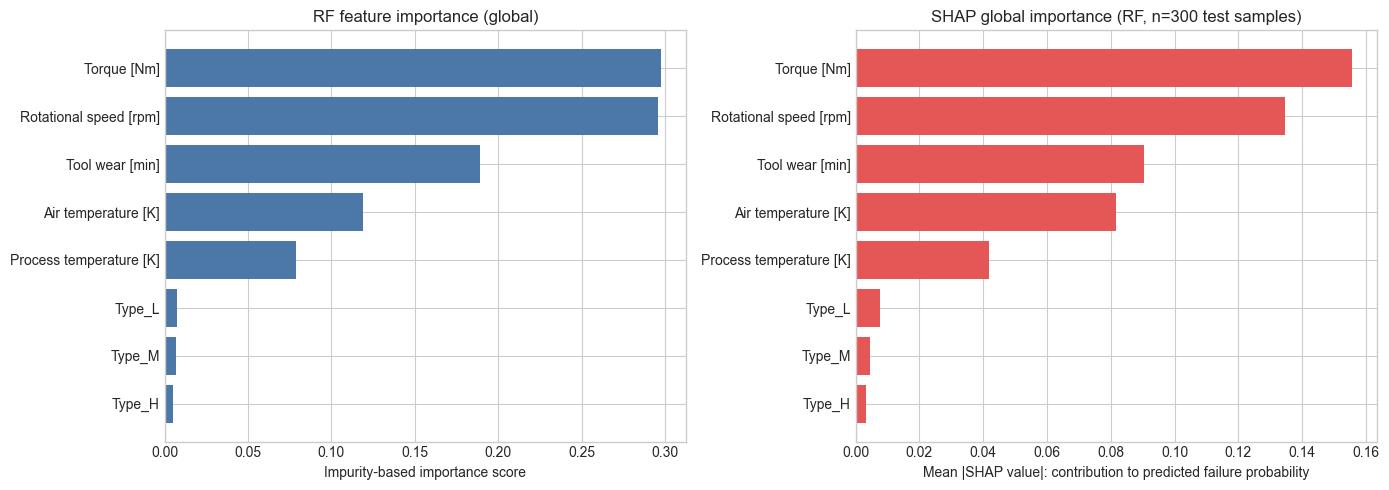

Top driver: Torque [Nm]

Maintenance implication: monitor torque and tool wear most closely.
A machine running at high torque with an ageing tool is the highest-priority inspection target.


In [29]:
# NOTE: Explainability: compute RF global importance and SHAP summaries
rf_model = trained_models['Random Forest']

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False)

shap_sample = X_test_prep[:300]
explainer = shap.TreeExplainer(rf_model)
raw_shap = explainer.shap_values(shap_sample)
shap_matrix = raw_shap[1] if isinstance(raw_shap, list) else (raw_shap[:, :, 1] if raw_shap.ndim == 3 else raw_shap)

shap_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': np.abs(shap_matrix).mean(axis=0)})
shap_df = shap_df.sort_values('Mean |SHAP|', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(imp_df['Feature'], imp_df['Importance'], color='#4C78A8')
axes[0].invert_yaxis()
axes[0].set_title('RF feature importance (global)')
axes[0].set_xlabel('Impurity-based importance score')

axes[1].barh(shap_df['Feature'], shap_df['Mean |SHAP|'], color='#E45756')
axes[1].invert_yaxis()
axes[1].set_title('SHAP global importance (RF, n=300 test samples)')
axes[1].set_xlabel('Mean |SHAP value|: contribution to predicted failure probability')

plt.tight_layout()
plt.show()

print(f'Top driver: {shap_df.iloc[0]["Feature"]}')
print()
print('Maintenance implication: monitor torque and tool wear most closely.')
print('A machine running at high torque with an ageing tool is the highest-priority inspection target.')

### Demo cases with LIME local explanations

Three machines from the test set cover three practical action levels:

- High risk: immediate inspection priority
- Review queue: above the model's operating threshold, but not confident enough to auto-escalate
- Low risk: continue monitoring

This makes it clear that "flagged" and "high risk" are not the same thing.

  Machine: Asset_04661  |  Type: L  |  Risk: High risk
  RF failure probability: 0.817
  Inspection flag: Flag for review / inspection
  Actual outcome: FAILURE
  Recommendation: Prioritise inspection before next production shift


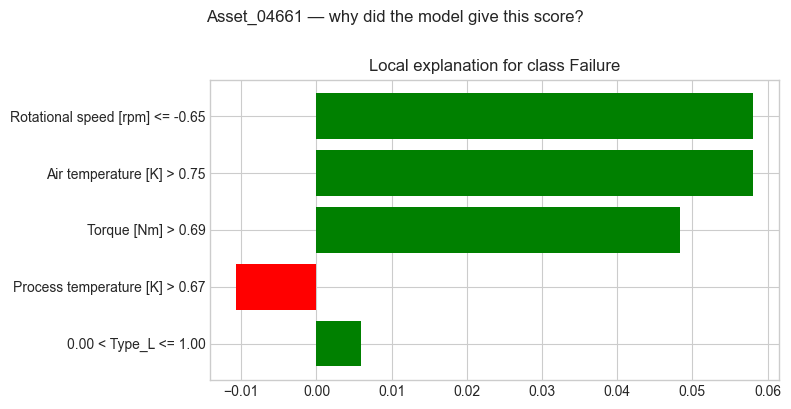

  Machine: Asset_06540  |  Type: M  |  Risk: Review queue
  RF failure probability: 0.290
  Inspection flag: Flag for review / inspection
  Actual outcome: FAILURE
  Recommendation: Flag for human review before scheduling inspection


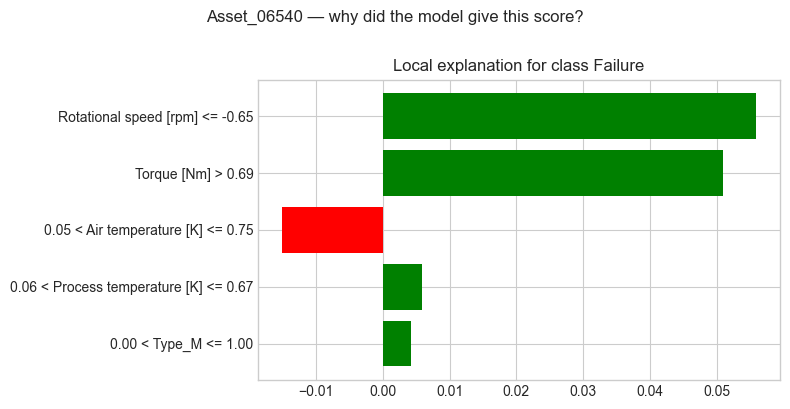

  Machine: Asset_08339  |  Type: M  |  Risk: Low risk
  RF failure probability: 0.000
  Inspection flag: No immediate action
  Actual outcome: no failure
  Recommendation: Continue monitoring


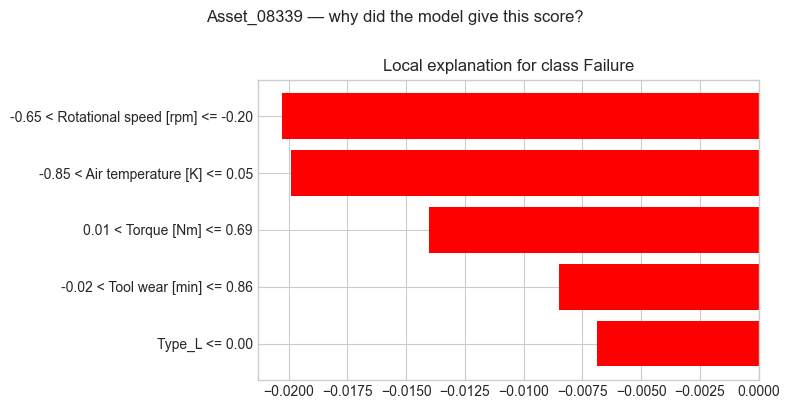

In [30]:
# NOTE: Demo dashboard and local explanations (LIME) for representative action levels
rf_threshold = optimal_thresholds['Random Forest']
rf_probs = probability_outputs_test['Random Forest']

def risk_band(p, threshold):
    if p >= 0.70:
        return 'High risk'
    if p >= 0.30:
        return 'Medium risk'
    if p >= threshold:
        return 'Review queue'
    return 'Low risk'

def recommendation(p, threshold):
    if p >= 0.70:
        return 'Prioritise inspection before next production shift'
    if p >= 0.30:
        return 'Inspect during next planned maintenance window'
    if p >= threshold:
        return 'Flag for human review before scheduling inspection'
    return 'Continue monitoring'

dashboard = X_test.copy()
dashboard['Machine ID'] = [f'Asset_{i:05d}' for i in dashboard.index]
dashboard['Actual outcome'] = y_test.values
dashboard['RF probability'] = rf_probs
dashboard['RF prediction'] = (rf_probs >= rf_threshold).astype(int)
dashboard['Inspection flag'] = np.where(
    dashboard['RF prediction'] == 1,
    'Flag for review / inspection',
    'No immediate action'
)
dashboard['Risk level'] = dashboard['RF probability'].apply(lambda p: risk_band(p, rf_threshold))
dashboard['Recommendation'] = dashboard['RF probability'].apply(lambda p: recommendation(p, rf_threshold))

lime_explainer = LimeTabularExplainer(
    training_data=X_train_prep,
    feature_names=feature_names,
    class_names=['No failure', 'Failure'],
    mode='classification',
)

def best_case(risk, ascending):
    sub = dashboard[dashboard['Risk level'] == risk]
    if sub.empty:
        sub = dashboard
    return sub.sort_values('RF probability', ascending=ascending).index[0]

demo_indices = [
    best_case('High risk', ascending=False),
    best_case('Review queue', ascending=False),
    best_case('Low risk', ascending=True),
]

for idx in demo_indices:
    row = dashboard.loc[idx]
    pos = list(X_test.index).index(idx)
    print(f"{'='*65}")
    print(f"  Machine: {row['Machine ID']}  |  Type: {row['Type']}  |  Risk: {row['Risk level']}")
    print(f"  RF failure probability: {row['RF probability']:.3f}")
    print(f"  Inspection flag: {row['Inspection flag']}")
    print(f"  Actual outcome: {'FAILURE' if row['Actual outcome'] else 'no failure'}")
    print(f"  Recommendation: {row['Recommendation']}")
    lime_exp = lime_explainer.explain_instance(
        X_test_prep[pos], rf_model.predict_proba, num_features=5
    )
    fig = lime_exp.as_pyplot_figure()
    fig.set_size_inches(8, 4)
    fig.suptitle(f"{row['Machine ID']} — why did the model give this score?", y=1.01)
    plt.tight_layout()
    plt.show()


---
### Maintenance recommendation dashboard

The table below shows the top 10 highest-probability assets in the test set. Two things are kept separate on purpose:

- Risk level: a plain-English probability band for engineers and managers
- Inspection flag: whether the machine crosses the validation-tuned operating threshold

In a real deployment, this view would refresh at the start of each shift and feed into the CMMS automatically.

In [31]:
# NOTE: Display top-10 risky assets and print concise test-set summary metrics
top10 = dashboard.sort_values('RF probability', ascending=False).head(10)
display(top10[[
    'Machine ID', 'Type', 'Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]',
    'Actual outcome', 'RF probability', 'Risk level', 'Inspection flag', 'Recommendation',
]].reset_index(drop=True))

rf_preds_arr = dashboard['RF prediction']
print(f"\nTest set summary  (RF threshold frozen from validation = {optimal_thresholds['Random Forest']:.2f}):")
print(f"  Total test records:              {len(y_test):,}")
print(f"  Actual failures in test set:     {y_test.sum()}")
print(f"  Machines flagged for inspection: {rf_preds_arr.sum()}")
print(f"  Failures correctly caught:       {((rf_preds_arr==1) & (y_test==1)).sum()}")
print(f"  Recall (coverage of failures):   {recall_score(y_test, rf_preds_arr):.1%}")
print(f"  Precision (inspection hit rate): {precision_score(y_test, rf_preds_arr):.1%}")


,Machine ID,Type,Torque [Nm],Tool wear [min],Rotational speed [rpm],Actual outcome,RF probability,Risk level,Inspection flag,Recommendation
0,Asset_04661,L,48.1,32,1350,1,0.816667,High risk,Flag for review / inspection,Prioritise inspection before next production s...
1,Asset_01391,L,8.8,142,2737,1,0.803333,High risk,Flag for review / inspection,Prioritise inspection before next production s...
2,Asset_07997,M,9.7,143,2710,1,0.786667,High risk,Flag for review / inspection,Prioritise inspection before next production s...
3,Asset_04081,L,58.2,110,1336,1,0.750000,High risk,Flag for review / inspection,Prioritise inspection before next production s...
4,Asset_04495,L,57.2,67,1359,1,0.736667,High risk,Flag for review / inspection,Prioritise inspection before next production s...
5,Asset_07011,L,12.2,17,2633,1,0.730000,High risk,Flag for review / inspection,Prioritise inspection before next production s...
6,Asset_04270,L,52.0,154,1331,1,0.726667,High risk,Flag for review / inspection,Prioritise inspection before next production s...
7,Asset_04080,L,58.0,108,1357,1,0.720000,High risk,Flag for review / inspection,Prioritise inspection before next production s...
8,Asset_06497,L,65.3,192,1312,1,0.706667,High risk,Flag for review / inspection,Prioritise inspection before next production s...
9,Asset_06078,L,59.1,203,1339,1,0.700000,High risk,Flag for review / inspection,Prioritise inspection before next production s...



Test set summary  (RF threshold frozen from validation = 0.04):
  Total test records:              2,000
  Actual failures in test set:     68
  Machines flagged for inspection: 240
  Failures correctly caught:       63
  Recall (coverage of failures):   92.6%
  Precision (inspection hit rate): 26.2%


---
## 6. Ethical Considerations

Deploying an AI system in an EV manufacturing setting raises a few issues worth thinking through properly, not just listing for completeness.

### 6.1 Fairness across machine types

As the fairness check shows, the model may not perform equally for L, M, and H-grade machines. If it misses more failures for one type, that production area gets less protection, which could mean more downtime there compared to other lines.

One way to address this is to monitor per-type recall monthly once the system is live and adjust thresholds by machine type if a consistent gap shows up.

### 6.2 Human-in-the-loop and deskilling

The model is designed to support maintenance engineers, not replace them. Recommendations are phrased as risk tiers rather than direct instructions. The longer-term concern is that engineers stop applying their own judgement if the system always seems correct, which erodes skills and becomes a problem if the model quietly degrades.

A practical guard against this: engineers should always be able to override any recommendation, and overrides should be logged with a reason. This protects engineers and feeds disagreements back into future model improvement. Periodic reminders that the model is a triage tool, not an authority, also help.

### 6.3 Accountability

If the model misses a failure that causes a stoppage or safety incident, there needs to be a clear accountability chain. "The AI said it was fine" is not a good answer in an industrial or regulatory setting.

Logging every prediction with the timestamp, machine ID, model version, probability, threshold, and LIME explanation creates an audit trail. Model versioning should be in place so you can roll back if something goes wrong.

### 6.4 Workforce impact

Predictive maintenance changes the nature of maintenance work: fewer routine scheduled checks, more targeted inspection and repair. That is not necessarily a bad thing, but it needs to be managed. Bringing the maintenance team into the rollout early helps, and framing AI as something that removes tedious work tends to land better than framing it as a replacement. Retraining on data interpretation and model oversight is worth budgeting for.

### 6.5 Data sensitivity

Production sensor data reveals things like machine utilisation rates, shift patterns, and output volumes, all of which are commercially sensitive. Data governance policies covering storage, retention, access control, and any cross-border data transfer need to be sorted out before go-live.

---
## 7. Risk Assessment

| Risk | Likelihood | Impact | Mitigation |
|---|---|---|---|
| Model misses a real failure (false negative) | Low at optimal threshold | High: unplanned downtime, potential safety event | Cost-optimal threshold; human review band; track recall weekly in production |
| Too many false alarms (false positives) | Medium | Medium: inspection fatigue, engineers start ignoring alerts | Monitor false alarm rate; raise threshold if alert-to-failure ratio gets too high |
| Concept drift: machine population or operating conditions change over time | Medium (long-term) | High: model degrades without retraining | Quarterly revalidation against recent labelled data; automated drift detection |
| Distribution shift: UCI proxy data is not JLR production data | High (at initial deployment) | High: model may not generalise to real JLR sensors | Shadow-mode pilot before acting on predictions; validate against JLR CMMS history |
| Sensor failure or data quality problems | Medium | High: model receives bad inputs, produces unreliable scores | Input validation; alert when readings fall outside expected operating ranges |
| Over-reliance by the maintenance team | Medium (long-term) | Medium: loss of diagnostic skill | Override logging; periodic checks without AI support; engineers own the recommendations |
| Cost ratio assumption is wrong | Medium | Medium: threshold tuned to FN=100×FP; real ratio may differ | Validate cost assumptions with JLR finance before finalising the threshold |
| Regulatory explainability requirements | Low–Medium | Medium | LIME explanations logged per prediction; model versioned and auditable |

---
## 8. Deployment Considerations

Taking this from a notebook demo to something running at JLR would need work across data infrastructure, model operations, and system integration. Here is what that would actually involve.

### Data pipeline
- Real-time sensor ingestion via MQTT or OPC-UA from PLCs into a time-series store (e.g. OSIsoft PI, InfluxDB, or Azure Time Series Insights).
- A feature engineering service that computes rolling statistics and wear counters at inference time.
- Target inference latency: under 1 second for real-time alerting; under 5 minutes for batch shift-start reports.

### Model operations (MLOps)
- Retraining cadence: monthly, using failures confirmed by engineers in the CMMS as new labelled data.
- Performance monitoring: weekly dashboard tracking recall, precision, and false alarm rate per production cell.
- Retraining trigger: if production recall drops more than 5 percentage points from the validated baseline, review immediately.
- Model registry: version control for all trained models with rollback capability.

### System integration
- High-risk predictions automatically raise a CMMS work order (e.g. in SAP PM) with the LIME explanation attached.
- Medium-risk predictions go onto a watchlist for the shift supervisor.
- Fault type predictions, where confidence is sufficient, could trigger pre-staged spare parts from stores.

### Rollout
1. Shadow mode (3 months): deploy on one line; generate predictions but do not act on them. Compare against actual outcomes.
2. Validate and calibrate: use the pilot results to check or adjust the cost ratio and threshold.
3. Live pilot (3 months): act on predictions for one line; measure actual downtime reduction against the baseline.
4. Phased expansion: roll out to the remaining lines with monthly checkpoint reviews and engineering sign-off at each stage.

---
## 8.1 Production Hardening and Path to Production

Note: this notebook does not start the Flask app. Its role is to train and evaluate the model, generate figures, and export the app artefacts. In a production setting, model training and app serving would be separate processes.

### Production-level fixes checklist
- Replace the Flask development server with a production WSGI/ASGI deployment behind a reverse proxy.
- Add authentication and authorisation for both the UI and prediction/API endpoints.
- Lock down file serving so only intended static assets can be read; avoid path traversal risks.
- Treat exported artefacts as trusted build outputs only; do not load untrusted `joblib` files.
- Add TLS, secret management, request logging, rate limiting, and monitoring.
- Pin dependency versions and run vulnerability scanning in CI/CD.
- Add structured input validation, request size limits, and operational alerting.
- Add model monitoring for drift, recall degradation, false alarm rate, and data quality failures.

### How to evolve this into a production system
- Data ingestion: stream machine telemetry from PLC/SCADA systems via OPC-UA, MQTT, Kafka, or an industrial gateway instead of reading a static dataset.
- Feature pipeline: move feature generation into a scheduled or streaming pipeline that computes rolling windows, deltas, counters, and wear indicators consistently for both training and inference.
- Training pipeline: convert notebook training into a reproducible pipeline job with versioned code, data snapshots, experiment tracking, and approval gates.
- Model registry: register approved models, thresholds, and metadata so deployment uses named, versioned artefacts rather than ad hoc notebook outputs.
- Batch and real-time scoring: support both plant-wide scheduled scoring and low-latency scoring for machines that need near-real-time intervention.
- Application layer: make the app a thin consumer of approved artefacts or an API-backed model service, not the place where training logic lives.
- CMMS/maintenance integration: push alerts into the maintenance workflow system so high-risk machines create or recommend work orders automatically.
- Observability: log feature values, predictions, thresholds, latency, and downstream outcomes for traceability and post-incident review.
- Retraining loop: define how confirmed failures, maintenance outcomes, and operator feedback are captured and fed back into the next training cycle.
- Governance: document model ownership, approval workflow, fallback mode, rollback plan, and the conditions under which the system must defer to human engineers.

### Target production architecture
1. Sensor and event data land in a governed industrial data platform.
2. A feature pipeline produces training tables and inference-ready feature views.
3. A scheduled training pipeline retrains, validates, and registers candidate models.
4. Approved models are deployed to a dedicated inference service.
5. The maintenance dashboard consumes scored outputs and explanation summaries from that service.
6. Alerts and recommendations flow into existing maintenance planning systems.

---
## 9. Critical Reflection and Limitations

### What this demonstrates

- There is a real signal in the sensor data before failure. The model is picking up something genuine, not just memorising noise.
- Choosing thresholds based on business cost (missed failure vs. false alarm) makes a meaningful difference compared to a fixed 0.5 cutoff.
- Selecting thresholds on a validation split and evaluating once on held-out data is the right approach; it prevents the threshold from being tuned directly to the test set.
- LIME explanations make each prediction interpretable at the machine level, so engineers can sanity-check the output before acting on it.
- Random Forest does best here, which fits the general finding that tree-based methods tend to work well on structured tabular data.

### What this does not show (and why it matters)

1. This is not real JLR data. The AI4I dataset is a simulation. Feature distributions, failure rates, and failure modes are illustrative. The cost ratio (FN = 100× FP) is assumed, not derived from JLR finance data. Any real deployment would need to be validated against JLR's own CMMS history first.

2. The model predicts failure likelihood, not timing. This is a binary classifier, not a Remaining Useful Life (RUL) model. A high-risk flag means the machine should be inspected, but the model cannot say whether that is in 2 hours or 2 shifts. A RUL model would need time-series run-to-failure data, which this dataset does not have.

3. Fault type classification is exploratory only. Around 300 single-mode failure records across 4 classes is not enough to build a reliable classifier. The side experiment suggests the signal is there, but it is too early to treat it as something deployable.

4. The model is a snapshot. It does not adapt to new machine types, process changes, or new product lines. Scheduled retraining is essential for long-term use, not optional.

5. Class imbalance handling was kept simple. Balanced class weights were used throughout. Alternatives like SMOTE, undersampling, or cost-sensitive loss functions were not tried. With very low failure rates (under 1%), more aggressive techniques may be needed in practice.

In [32]:
# NOTE: Export everything the app needs directly from this notebook run
print('\nValidation-tuned thresholds for production use:')
for name, t in optimal_thresholds.items():
    print(f'  {name}: {t:.2f}')

SCENARIO_PRESETS = {
    'Worn tool': {'Type': 'L', 'Air temperature [K]': 300.0, 'Process temperature [K]': 309.4, 'Rotational speed [rpm]': 1420, 'Torque [Nm]': 61.0, 'Tool wear [min]': 225},
    'Overstrain': {'Type': 'M', 'Air temperature [K]': 299.5, 'Process temperature [K]': 308.1, 'Rotational speed [rpm]': 1310, 'Torque [Nm]': 66.0, 'Tool wear [min]': 170},
    'Running hot': {'Type': 'H', 'Air temperature [K]': 303.5, 'Process temperature [K]': 313.6, 'Rotational speed [rpm]': 1510, 'Torque [Nm]': 49.0, 'Tool wear [min]': 140},
    'Healthy': {'Type': 'L', 'Air temperature [K]': 300.0, 'Process temperature [K]': 310.0, 'Rotational speed [rpm]': 1500, 'Torque [Nm]': 55.0, 'Tool wear [min]': 180},
}
LOCATION_MAP = [('BIW-North', 'Trim Line A'), ('BIW-North', 'Spot Weld 3'), ('Paint-East', 'Robot Cell 7'), ('Assembly-S2', 'Conveyor B'), ('BIW-North', 'Mill Station 2'), ('Drive Hall', 'Drive Motor 4'), ('Trim-West', 'Trim Line C'), ('Machining', 'Mill Station 5'), ('Paint-East', 'Robot Cell 2'), ('Drill Zone', 'Drill Stn 1'), ('Drive Hall', 'Spindle 9'), ('Assembly-S2', 'Conveyor F'), ('Trim-West', 'Trim Line B'), ('Paint-East', 'Robot Cell 5'), ('Machining', 'Mill Station 1')]
ASSET_CODES = ['CNC', 'CNC', 'RBT', 'CNV', 'CNC', 'MTR', 'CNC', 'CNC', 'RBT', 'CNC', 'MTR', 'CNV', 'CNC', 'RBT', 'CNC']
COST_FN = 1000
COST_FP = 10
THRESH_GRID = np.linspace(0.01, 0.99, 199)

def serialise_value(value):
    if isinstance(value, dict):
        return {str(key): serialise_value(val) for key, val in value.items()}
    if isinstance(value, list):
        return [serialise_value(item) for item in value]
    if isinstance(value, tuple):
        return [serialise_value(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    return value

def risk_band(p, threshold):
    if p >= 0.70:
        return 'HIGH'
    if p >= 0.30:
        return 'MEDIUM'
    if p >= threshold:
        return 'REVIEW'
    return 'LOW'

def recommendation_text(p, threshold):
    if p >= 0.70:
        return 'Inspect before next shift'
    if p >= 0.30:
        return 'Inspect during next planned window'
    if p >= threshold:
        return 'Flag for human review'
    return 'Continue monitoring'

def inspection_flag(p, threshold):
    return p >= threshold

def feature_key_from_rule(feature_rule):
    rule = feature_rule.lower()
    if 'tool wear' in rule:
        return 'Tool wear [min]'
    if 'torque' in rule:
        return 'Torque [Nm]'
    if 'rotational speed' in rule or 'speed' in rule:
        return 'Rotational speed [rpm]'
    if 'process temperature' in rule:
        return 'Process temperature [K]'
    if 'air temperature' in rule:
        return 'Air temperature [K]'
    if 'type_' in rule:
        return 'Type'
    return None

def current_value_label(feature_key, row):
    if feature_key is None:
        return 'Current value unavailable'
    if feature_key == 'Type':
        return f"Current grade: {row['Type']}"
    value = row[feature_key]
    if feature_key == 'Tool wear [min]':
        return f'Current value: {int(round(float(value)))} min'
    if feature_key == 'Rotational speed [rpm]':
        return f'Current value: {int(round(float(value)))} rpm'
    if feature_key == 'Torque [Nm]':
        return f'Current value: {round(float(value), 1)} Nm'
    return f'Current value: {round(float(value), 1)} K'

def issue_summary(lime_items):
    labels = []
    for item in lime_items:
        if item['contribution'] <= 0:
            continue
        rule = item['feature_rule'].lower()
        if 'tool wear' in rule:
            label = 'Worn tool'
        elif 'torque' in rule:
            label = 'High torque'
        elif 'rotational speed' in rule or 'speed' in rule:
            label = 'Low speed'
        elif 'process temperature' in rule:
            label = 'Running hot'
        elif 'air temperature' in rule:
            label = 'Hot air'
        elif 'type_' in rule:
            label = 'Machine grade pattern'
        else:
            label = item['feature_rule']
        if label not in labels:
            labels.append(label)
        if len(labels) == 2:
            break
    return ', '.join(labels) if labels else 'General sensor drift'

def cost_curve(probabilities, y_true):
    values = []
    for threshold in THRESH_GRID:
        preds = (probabilities >= threshold).astype(int)
        fn = int(((y_true == 1) & (preds == 0)).sum())
        fp = int(((y_true == 0) & (preds == 1)).sum())
        values.append({'threshold': float(threshold), 'cost': float(fn * COST_FN + fp * COST_FP)})
    return values

def normalise_curve(curve):
    costs = np.array([point['cost'] for point in curve], dtype=float)
    lo = float(costs.min())
    hi = float(costs.max())
    span = max(hi - lo, 1.0)
    return [{'threshold': point['threshold'], 'value': float((point['cost'] - lo) / span)} for point in curve]

rf_model = trained_models['Random Forest']
rf_threshold = float(optimal_thresholds['Random Forest'])
rf_probs = probability_outputs_test['Random Forest']
dashboard_export = X_test.copy()
dashboard_export['Machine ID'] = [f'Asset_{i:05d}' for i in dashboard_export.index]
dashboard_export['Actual outcome'] = y_test.values
dashboard_export['RF probability'] = rf_probs
dashboard_export['RF prediction'] = opt_preds['Random Forest']
dashboard_export['Confidence'] = np.maximum(rf_probs, 1 - rf_probs)
dashboard_export['Risk level'] = [risk_band(float(p), rf_threshold) for p in rf_probs]
dashboard_export['Recommendation'] = [recommendation_text(float(p), rf_threshold) for p in rf_probs]
dashboard_export['Inspection flag'] = [inspection_flag(float(p), rf_threshold) for p in rf_probs]

lime_explainer = LimeTabularExplainer(training_data=X_train_prep, feature_names=feature_names, class_names=['No failure', 'Failure'], mode='classification')
flagged = dashboard_export[dashboard_export['Inspection flag']].sort_values('RF probability', ascending=False)
high = flagged[flagged['Risk level'] == 'HIGH'].head(7)
mid = flagged[flagged['Risk level'] != 'HIGH'].head(6)
low = dashboard_export[~dashboard_export.index.isin(pd.concat([high, mid]).index)].sort_values('RF probability', ascending=True).head(17)
fleet_df = pd.concat([high, mid, low], axis=0).copy().sort_values('RF probability', ascending=False).reset_index()

fleet = []
top_machines = []
machine_details = {}
for position, row in fleet_df.iterrows():
    source_index = int(row['index'])
    area, station = LOCATION_MAP[position % len(LOCATION_MAP)]
    asset_code = ASSET_CODES[position % len(ASSET_CODES)]
    machine_id = f'AURORA-{asset_code}-{source_index:05d}'
    test_position = list(X_test.index).index(source_index)
    lime_exp = lime_explainer.explain_instance(X_test_prep[test_position], rf_model.predict_proba, num_features=5)
    lime_items = []
    for rule, contribution in lime_exp.as_list():
        feature_key = feature_key_from_rule(rule)
        lime_items.append({'feature_rule': rule, 'featureKey': feature_key, 'currentValueLabel': current_value_label(feature_key, row), 'contribution': float(contribution)})
    summary_text = issue_summary(lime_items)
    display_risk = 'MEDIUM' if row['Risk level'] == 'REVIEW' else row['Risk level']
    base = {'machineId': machine_id, 'sourceIndex': source_index, 'type': row['Type'], 'area': area, 'station': station, 'probability': float(row['RF probability']), 'confidence': float(row['Confidence']), 'risk': display_risk, 'internalRisk': row['Risk level'], 'inspectionFlag': bool(row['Inspection flag']), 'recommendation': row['Recommendation'], 'actualOutcome': int(row['Actual outcome']), 'summary': summary_text}
    fleet.append(base)
    if position < 5:
        top_machines.append({**base, 'rank': position + 1, 'riskPercent': round(float(row['RF probability']) * 100)})
    machine_details[machine_id] = {**base, 'predictionPercent': round(float(row['RF probability']) * 100), 'sensorReadings': {'Torque [Nm]': round(float(row['Torque [Nm]']), 1), 'Tool wear [min]': int(round(float(row['Tool wear [min]']))), 'Rotational speed [rpm]': int(round(float(row['Rotational speed [rpm]']))), 'Process temperature [K]': round(float(row['Process temperature [K]']), 1), 'Air temperature [K]': round(float(row['Air temperature [K]']), 1)}, 'lime': lime_items}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
class_counts = df['Machine failure'].value_counts().sort_index()
axes[0].bar(['No failure', 'Failure'], [int(class_counts.get(0, 0)), int(class_counts.get(1, 0))], color=['#6f7a88', '#ff6b6b'])
axes[0].set_title('Class balance')
axes[0].set_ylabel('Records')
failure_mode_counts = df.loc[df['Machine failure'] == 1, FAILURE_MODE_COLS].sum().sort_values(ascending=False)
axes[1].bar(failure_mode_counts.index.tolist(), failure_mode_counts.values.tolist(), color='#67ccb0')
axes[1].set_title('Failure mode frequency')
axes[1].set_ylabel('Count')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'class_balance.png', dpi=160, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Logistic Regression': '#6f7a88', 'Random Forest': '#67ccb0', 'TabNet': '#f4c056'}
for name, probs in probability_outputs_val.items():
    curve = cost_curve(probs, y_val)
    ax.plot([point['threshold'] for point in curve], [point['cost'] for point in curve], label=f"{name} (t={optimal_thresholds[name]:.2f})", color=colors.get(name, '#ffffff'))
    ax.axvline(optimal_thresholds[name], linestyle=':', color=colors.get(name, '#ffffff'), alpha=0.6)
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Estimated operational cost (GBP proxy)')
ax.set_title('Validation cost curves and chosen operating points')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'threshold_cost_curves.png', dpi=160, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
for name, probs in probability_outputs_test.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=colors.get(name, '#ffffff'))
ax.plot([0, 1], [0, 1], linestyle='--', color='#9fb4c7')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('Held-out test ROC curves')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'roc_curves.png', dpi=160, bbox_inches='tight')
plt.close(fig)

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False)
shap_sample = X_test_prep[:300]
explainer = shap.TreeExplainer(rf_model)
raw_shap = explainer.shap_values(shap_sample)
shap_matrix = raw_shap[1] if isinstance(raw_shap, list) else (raw_shap[:, :, 1] if raw_shap.ndim == 3 else raw_shap)
shap_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': np.abs(shap_matrix).mean(axis=0)}).sort_values('Mean |SHAP|', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(imp_df['Feature'], imp_df['Importance'], color='#4C78A8')
axes[0].invert_yaxis()
axes[0].set_title('RF feature importance')
axes[1].barh(shap_df['Feature'], shap_df['Mean |SHAP|'], color='#E45756')
axes[1].invert_yaxis()
axes[1].set_title('RF SHAP mean absolute contribution')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'rf_global_importance.png', dpi=160, bbox_inches='tight')
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for idx, name in enumerate(['Logistic Regression', 'Random Forest', 'TabNet']):
    matrix = confusion_matrix(y_test, opt_preds[name])
    ConfusionMatrixDisplay(confusion_matrix=matrix).plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(name)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.close(fig)

flagged_count = sum(1 for item in fleet if item['inspectionFlag'])
high_risk_count = sum(1 for item in fleet if item['risk'] == 'HIGH')
true_positives = sum(1 for item in fleet if item['inspectionFlag'] and item['actualOutcome'] == 1)
threshold_curves = {name: normalise_curve(cost_curve(probabilities, y_test)) for name, probabilities in probability_outputs_test.items()}
cost_column = 'Est. cost (GBP)' if 'Est. cost (GBP)' in results_df.columns else 'Est. cost (£)'
models_payload = [{'name': row['Model'], 'winner': row['Model'] == str(results_df.iloc[0]['Model']), 'recall': row['Recall'], 'precision': row['Precision'], 'auc': row['ROC-AUC'], 'cost': row[cost_column], 'threshold': row['Threshold']} for row in results_df.to_dict(orient='records')]
app_payload = {
    'overview': {'plant': 'JLR Plant 2, Solihull', 'title': 'Predictive maintenance pilot', 'subtitle': 'The model looks at sensor data from every machine on the line and flags the ones most likely to fail in the next shift. Engineers inspect those first, before anything breaks.', 'summary': {'machinesMonitored': len(fleet), 'flaggedToday': flagged_count, 'highRisk': high_risk_count, 'downtimeAvoidedHours': true_positives * 2}, 'topMachines': top_machines},
    'machines': {'machines': [item for item in fleet if item['inspectionFlag']]},
    'machineDetails': machine_details,
    'tryIt': {'threshold': rf_threshold, 'typeOptions': sorted(df['Type'].unique().tolist()), 'featureDefaults': SCENARIO_PRESETS['Healthy'], 'featureBounds': {column: {'min': None if column == 'Type' else float(df[column].min()), 'max': None if column == 'Type' else float(df[column].max())} for column in FEATURE_COLS}, 'scenarios': SCENARIO_PRESETS},
    'howItWorks': {'headlineMetrics': {'recall': float(results_df.loc[results_df['Model'] == 'Random Forest', 'Recall'].iloc[0]), 'precision': float(results_df.loc[results_df['Model'] == 'Random Forest', 'Precision'].iloc[0]), 'auc': float(results_df.loc[results_df['Model'] == 'Random Forest', 'ROC-AUC'].iloc[0])}, 'models': models_payload, 'threshold': round(rf_threshold, 2), 'thresholdCurves': threshold_curves, 'curveDomain': {'min': 0.0, 'max': 1.0}, 'figurePaths': {'classBalance': '/figures/class_balance.png', 'costCurves': '/figures/threshold_cost_curves.png', 'rocCurves': '/figures/roc_curves.png', 'rfImportance': '/figures/rf_global_importance.png', 'confusionMatrices': '/figures/confusion_matrices.png'}},
    'resultsTable': results_df.to_dict(orient='records'),
    'top10Table': dashboard_export.sort_values('RF probability', ascending=False).head(10)[['Machine ID', 'Type', 'Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]', 'Actual outcome', 'RF probability', 'Risk level', 'Inspection flag', 'Recommendation']].reset_index(drop=True).to_dict(orient='records'),
}

bundle_payload = {'preprocessor': preprocessor, 'rf_model': trained_models['Random Forest'], 'threshold': rf_threshold, 'meta': app_payload['tryIt']}
APP_PAYLOAD_PATH.write_text(json.dumps(serialise_value(app_payload), indent=2), encoding='utf-8')
joblib.dump(bundle_payload, MODEL_BUNDLE_PATH)
print(f'\nApp payload saved: {APP_PAYLOAD_PATH}')
print(f'Model bundle saved: {MODEL_BUNDLE_PATH}')
print('\nAll artefacts saved.')



Validation-tuned thresholds for production use:
  Logistic Regression: 0.32
  Random Forest: 0.04
  TabNet: 0.01

App payload saved: C:\Users\amyna\OneDrive - University of Warwick\AI for industry\Group_work\artifacts\app_payload.json
Model bundle saved: C:\Users\amyna\OneDrive - University of Warwick\AI for industry\Group_work\artifacts\model_bundle.joblib

All artefacts saved.
